# **ET - Programación para Ciencia de Datos**
## Profesor: Pablo Espinoza Quilaqueo
## Sección: 801V
## Integrantes:
* Areliz Isla Treuque
* Daniela Montefinale Middleton

# 1. Comprensión del problema

## 1.1 Contexto del problema

Las emisiones de CO₂ son el principal indicador del impacto ambiental de la matriz energética de un país. Sin embargo, no todos los países emiten por las mismas razones: algunos dependen fuertemente de combustibles fósiles para generar electricidad, otros tienen economías intensivas en energía, y otros presentan altos niveles de consumo per cápita asociados a su desarrollo económico.

Este proyecto utiliza el dataset **Global Data on Sustainable Energy (2000-2020)**, con datos reales del Banco Mundial y la IEA para 176 países, y lo enriquece con dos indicadores adicionales obtenidos directamente desde la API del World Bank (población total y porcentaje de urbanización).

**Pregunta central:** ¿Es posible estimar las emisiones de CO₂ de un país a partir de su perfil energético y económico, con precisión suficiente para complementar los registros faltantes?

**Caso de uso:** el problema no es hipotético, está en el propio dataset. De las 3.649 observaciones, 428 no tienen dato de emisiones, y 13 países no reportan en ningún año del período. Existen países que informan su matriz energética pero no sus emisiones de CO₂, por lo que estimarlas a partir del comportamiento de países comparables tiene valor práctico concreto para completar registros incompletos.

## 1.2 Definición de la variable objetivo

La variable objetivo es `Value_co2_emissions_kt_by_country`, que representa las emisiones anuales de CO₂ de cada país, medidas en kilotoneladas (kt).

Al ser una variable numérica continua, el problema se aborda como una regresión. El modelo estima el nivel de emisiones a partir de variables energéticas (generación por fuente, consumo per cápita, intensidad energética), económicas (PIB per cápita, crecimiento del PIB) y demográficas (población, urbanización, densidad).

El objetivo es predictivo, no explicativo: interesa la precisión de la estimación, no establecer relaciones causales entre las variables y las emisiones.

## 1.3 Diccionario de variables

| Variable (nombre final) | Descripción | Unidad / Tipo |
|---|---|---|
| Pais | Nombre del país | Categórica |
| Anio | Año de la observación (2000-2020) | Entero |
| Acceso_electricidad | Acceso a electricidad | % de la población |
| Acceso_combustible_limpio | Acceso a combustibles limpios para cocinar | % de la población |
| Capacidad_renovable_pc | Capacidad instalada de generación renovable per cápita | W/persona |
| Flujos_financieros | Flujos financieros hacia países en desarrollo para energía limpia | US$ |
| Renovable_pct | Participación renovable en el consumo final de energía | % |
| Renovable_energia_primaria_pct | Renovables como equivalente de energía primaria | % |
| Elec_fossil | Electricidad generada con combustibles fósiles | TWh |
| Elec_nuclear | Electricidad generada con energía nuclear | TWh |
| Elec_renovables | Electricidad generada con renovables | TWh |
| Bajo_carbon_pct | Electricidad baja en carbono (nuclear + renovables) | % de la electricidad |
| Consumo_ener_pc | Consumo de energía primaria per cápita | kWh/persona |
| Intensidad_energia | Intensidad energética de la energía primaria | MJ por $2017 PPP de PIB |
| **Emision_CO2 (target)** | Emisiones anuales de CO₂ del país | kilotoneladas (kt) |
| Gdp_crecimiento | Crecimiento anual del PIB | % |
| Gdp_pc | PIB per cápita | USD |
| Densidad | Densidad poblacional | personas/km² |
| Area_Kkm2 | Superficie del país | km² |
| Latitud / Longitud | Coordenadas del país | Grados |
| Poblacion (API) | Población total (World Bank, SP.POP.TOTL) | Personas |
| Urbanizacion (API) | Población urbana (World Bank, SP.URB.TOTL.IN.ZS) | % de la población |
| renovable_ratio (derivada) | Electricidad renovable sobre el total generado | Proporción 0-1 |

# 2. Fase Extracción

## 2.1 Importación de librerías

In [1]:
#CORRER ESTA CELDA PRIMERO SOLA PARA CREAR LA CARPETA RAW, DONDE SE COPIA EL DATASET ORIGINAL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests
!pip install pycountry
import pycountry
import os

# Random state global para reproducibilidad (split y Random Forest)
RANDOM_STATE = 42

os.makedirs("data/raw", exist_ok=True)


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2.2 Extracción del CSV principal

In [2]:
def extract_csv(path):
    """Carga el CSV principal desde data/raw/."""
    df = pd.read_csv(path)
    return df

df = extract_csv("data/raw/global-data-on-sustainable-energy.csv")
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [3]:
df.shape

(3649, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   str    
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels (TWh)         

In [5]:
df.describe()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
count,3649.000000,3639.000000,3480.000000,2718.000000,1.560000e+03,3455.000000,3628.000000,3523.000000,3628.000000,3607.000000,3649.000000,3442.000000,3.221000e+03,1512.000000,3332.000000,3367.000000,3.648000e+03,3648.000000,3648.000000
mean,2010.038367,78.933702,63.255287,113.137498,9.422400e+07,32.638165,70.365003,13.450190,23.968010,36.801182,25743.981745,5.307345,1.598665e+05,11.986707,3.441610,13283.774348,6.332135e+05,18.246388,14.822695
std,6.054228,30.275541,39.043658,244.167256,2.981544e+08,29.894901,348.051866,73.006623,104.431085,34.314884,34773.221366,3.532020,7.736611e+05,14.994644,5.686720,19709.866716,1.585519e+06,24.159232,66.348148
min,2000.000000,1.252269,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110000,1.000000e+01,0.000000,-62.075920,111.927225,2.100000e+01,-40.900557,-175.198242
25%,2005.000000,59.800890,23.175000,3.540000,2.600000e+05,6.515000,0.290000,0.000000,0.040000,2.877847,3116.737300,3.170000,2.020000e+03,2.137095,1.383302,1337.813437,2.571300e+04,3.202778,-11.779889
50%,2010.000000,98.361570,83.150000,32.910000,5.665000e+06,23.300000,2.970000,0.000000,1.470000,27.865068,13120.570000,4.300000,1.050000e+04,6.290766,3.559855,4578.633208,1.176000e+05,17.189877,19.145136
75%,2015.000000,100.000000,100.000000,112.210000,5.534750e+07,55.245000,26.837500,0.000000,9.600000,64.403792,33892.780000,6.027500,6.058000e+04,16.841638,5.830099,15768.615365,5.131200e+05,38.969719,46.199616
max,2020.000000,100.000000,100.000000,3060.190000,5.202310e+09,96.040000,5184.130000,809.410000,2184.940000,100.000010,262585.700000,32.570000,1.070722e+07,86.836586,123.139555,123514.196700,9.984670e+06,64.963051,178.065032


## 2.3 Mapeo de países a códigos ISO3

La API del World Bank identifica países por código ISO3 (CHL, ARG, USA), mientras que el dataset usa nombres completos en la columna `Entity`. Se usa `pycountry` para el mapeo, con corrección manual de los nombres que no calcen.

In [6]:
def country_to_iso3(name):
    """Convierte nombre de país a código ISO3. Devuelve None si no hay match."""
    try:
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        return None

df["iso3"] = df["Entity"].apply(country_to_iso3)

# Revisión de países sin match
df[df["iso3"].isnull()]["Entity"].unique()

<StringArray>
['Turkey']
Length: 1, dtype: str

In [7]:
# Mapeo manual de los países que pycountry no reconoce
# (pycountry registra a Turkey como Türkiye, por eso el lookup falla)
mapeo_manual = {"Turkey": "TUR"}

df["iso3"] = df["iso3"].fillna(df["Entity"].map(mapeo_manual))

# Verificación: no deben quedar países sin ISO3
df["iso3"].isnull().sum()

np.int64(0)

### **Observaciones:**

* El único país que pycountry no reconoce directamente es Turkey (registrado como Türkiye en la librería), que se corrige con un mapeo manual a TUR.
* Tras la corrección, las 3.649 filas quedan con código ISO3 asignado, lo que habilita el cruce con la API.

## 2.4 Extracción desde la API del World Bank

Se traen dos indicadores por país y año, con llave de cruce ISO3 + año:

| Indicador | Código API | Justificación |
|---|---|---|
| Población total | `SP.POP.TOTL` | Más población implica más emisiones totales |
| Urbanización (%) | `SP.URB.TOTL.IN.ZS` | Mayor urbanización implica mayor consumo energético |

In [8]:
import os
import time
import requests
import pandas as pd
from tqdm.auto import tqdm

def extract_worldbank(indicator, countries_iso3, start=2000, end=2020,
                      output_path=None, max_retries=3, timeout=15):

    if output_path is None:
        output_path = f"data/raw/{indicator}.csv"

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Revisar si ya existe un archivo parcial
    if os.path.exists(output_path):
        df_existing = pd.read_csv(output_path)
        downloaded = set(df_existing["iso3"].unique())
        print(f"Se encontraron {len(downloaded)} países ya descargados.")
    else:
        downloaded = set()

    pending = [iso3 for iso3 in countries_iso3 if iso3 not in downloaded]

    print(f"Pendientes: {len(pending)} de {len(countries_iso3)} países.")

    for iso3 in tqdm(pending, desc=indicator, unit="país"):
        url = f"https://api.worldbank.org/v2/country/{iso3}/indicator/{indicator}"
        params = {"date": f"{start}:{end}", "format": "json", "per_page": 100}

        data = None

        for intento in range(max_retries):
            try:
                response = requests.get(url, params=params, timeout=timeout)
                response.raise_for_status()
                data = response.json()
                break
            except (requests.exceptions.RequestException,
                    requests.exceptions.JSONDecodeError):
                espera = 2 ** (intento + 1)
                print(f"[{iso3}] intento {intento+1}/{max_retries}. "
                      f"Reintentando en {espera}s...")
                time.sleep(espera)

        if data is None:
            print(f"Se omitió {iso3}")
            continue

        if len(data) > 1 and data[1]:
            rows = [{"iso3": iso3, "year": int(entry["date"]), "value": entry["value"]
            } for entry in data[1]]
            df_country = pd.DataFrame(rows)

            df_country.to_csv(output_path, mode="a", header=not os.path.exists(output_path), index=False)
        time.sleep(0.5)

    return pd.read_csv(output_path)

In [9]:
# Lista de países presentes en el dataset
paises_iso3 = df["iso3"].unique().tolist()

# Extrae los indicadores del World Bank.
# Si existen archivos parciales, la descarga se reanuda automáticamente.
df_population = extract_worldbank("SP.POP.TOTL", paises_iso3)
df_urbanization = extract_worldbank("SP.URB.TOTL.IN.ZS", paises_iso3)

# Renombrar la columna value de cada DataFrame antes del merge,
# para que no colisionen como value_x / value_y
df_population = df_population.rename(columns={"value": "Poblacion"})
df_urbanization = df_urbanization.rename(columns={"value": "Urbanizacion"})

print("Población:", df_population.shape)
print("Urbanización:", df_urbanization.shape)

Se encontraron 174 países ya descargados.
Pendientes: 2 de 176 países.


SP.POP.TOTL:   0%|          | 0/2 [00:00<?, ?país/s]

[ALB] intento 1/3. Reintentando en 2s...
Se encontraron 174 países ya descargados.
Pendientes: 2 de 176 países.


SP.URB.TOTL.IN.ZS:   0%|          | 0/2 [00:00<?, ?país/s]

Población: (3675, 3)
Urbanización: (3675, 3)


### **Observaciones:**

* Ambos indicadores devolvieron 3.675 filas. Con 176 países y 21 años el máximo posible serían 3.696, así que la API no entregó 21 registros en cada uno.

## 2.5 Normalización de nombres y tipos

In [10]:
# Se renombran todas las columnas existentes para mejor legibilidad y comprensión
rename_map = {
    "Entity": "Pais",
    "Year": "Anio",
    "Access to electricity (% of population)": "Acceso_electricidad",
    "Access to clean fuels for cooking": "Acceso_combustible_limpio",
    "Renewable-electricity-generating-capacity-per-capita": "Capacidad_renovable_pc",
    "Financial flows to developing countries (US $)": "Flujos_financieros",
    "Renewable energy share in the total final energy consumption (%)": "Renovable_pct",
    "Renewables (% equivalent primary energy)": "Renovable_energia_primaria_pct",
    "Electricity from fossil fuels (TWh)": "Elec_fossil",
    "Electricity from nuclear (TWh)": "Elec_nuclear",
    "Electricity from renewables (TWh)": "Elec_renovables",
    "Low-carbon electricity (% electricity)": "Bajo_carbon_pct",
    "Primary energy consumption per capita (kWh/person)": "Consumo_ener_pc",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)": "Intensidad_energia",
    "Value_co2_emissions_kt_by_country": "Emision_CO2",
    "Land Area(Km2)": "Area_Kkm2",
    "Latitude": "Latitud",
    "Longitude": "Longitud",
    "gdp_growth": "Gdp_crecimiento",
    "gdp_per_capita": "Gdp_pc"
}
df = df.rename(columns=rename_map)
df.columns.tolist()

['Pais',
 'Anio',
 'Acceso_electricidad',
 'Acceso_combustible_limpio',
 'Capacidad_renovable_pc',
 'Flujos_financieros',
 'Renovable_pct',
 'Elec_fossil',
 'Elec_nuclear',
 'Elec_renovables',
 'Bajo_carbon_pct',
 'Consumo_ener_pc',
 'Intensidad_energia',
 'Emision_CO2',
 'Renovable_energia_primaria_pct',
 'Gdp_crecimiento',
 'Gdp_pc',
 'Density\\n(P/Km2)',
 'Area_Kkm2',
 'Latitud',
 'Longitud',
 'iso3']

El nombre de la columna de densidad contiene un salto de línea literal (`\n`), por lo que se identifica por prefijo en vez de escribirla a mano. Además, sus valores vienen como texto con separador de miles.

In [11]:
# Identificar la columna por prefijo (su nombre contiene caracteres problemáticos)
col_densidad = [c for c in df.columns if c.startswith("Density")][0]

# Conversión a numérico, eliminando separador de miles
df["Densidad"] = pd.to_numeric(
    df[col_densidad].str.replace(",", ""),
    errors="coerce"
)

# Se elimina la columna original
df = df.drop(columns=[col_densidad])

# Verificación
print("Tipo:", df["Densidad"].dtype)
print("Nulos generados por la conversión:", df["Densidad"].isnull().sum())

Tipo: float64
Nulos generados por la conversión: 1


### **Observaciones:**

* La conversión a numérico genera solo 1 nulo (un valor que no era parseable), que se resolverá en la etapa de imputación.

# 3. Comprensión de los datos

## 3.1 Diagnóstico de datos faltantes e inconsistencias

In [12]:
# Porcentaje de nulos por columna, ordenado de mayor a menor
nulos_pct = (df.isnull().sum() / len(df) * 100).round(1).sort_values(ascending=False)
nulos_pct

Renovable_energia_primaria_pct    58.6
Flujos_financieros                57.2
Capacidad_renovable_pc            25.5
Emision_CO2                       11.7
Gdp_crecimiento                    8.7
Gdp_pc                             7.7
Intensidad_energia                 5.7
Renovable_pct                      5.3
Acceso_combustible_limpio          4.6
Elec_nuclear                       3.5
Bajo_carbon_pct                    1.2
Elec_fossil                        0.6
Elec_renovables                    0.6
Acceso_electricidad                0.3
Pais                               0.0
Anio                               0.0
Consumo_ener_pc                    0.0
Area_Kkm2                          0.0
Latitud                            0.0
Longitud                           0.0
iso3                               0.0
Densidad                           0.0
dtype: float64

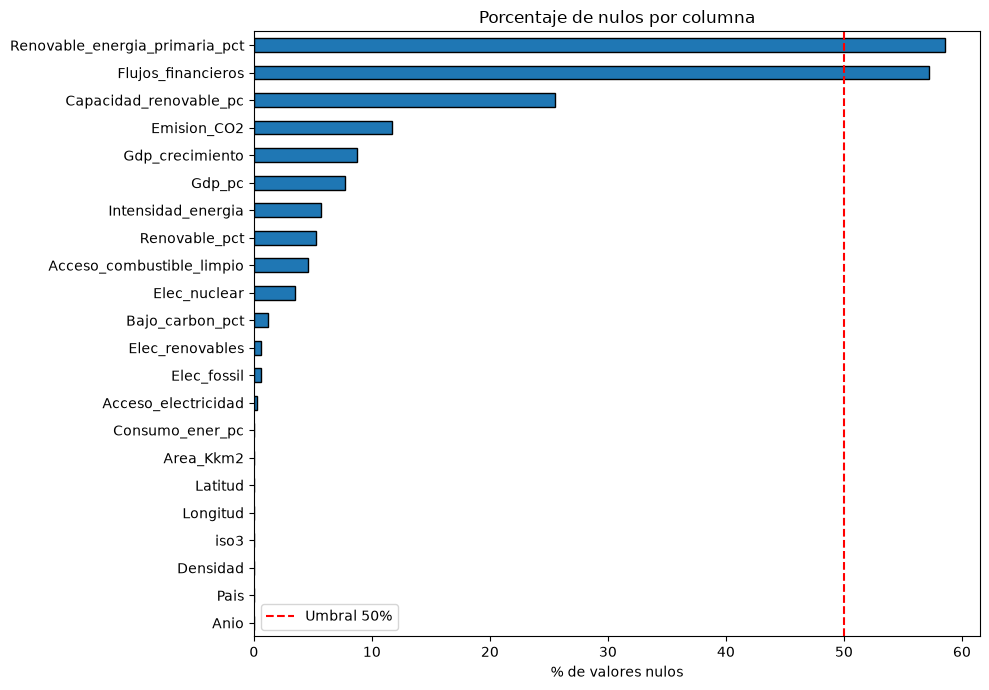

In [13]:
# Visualización del porcentaje de nulos por columna
fig, ax = plt.subplots(figsize=(10, 7))
nulos_pct.sort_values().plot(kind="barh", ax=ax, edgecolor="black")
ax.axvline(50, color="red", linestyle="--", label="Umbral 50%")
ax.set_xlabel("% de valores nulos")
ax.set_title("Porcentaje de nulos por columna")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Patrón de los nulos: ¿concentrados en las mismas filas o dispersos?
cols_altas = [c for c in df.columns if df[c].isnull().mean() > 0.5]

print("Filas con al menos un nulo (todas las columnas):", df.isnull().any(axis=1).sum(), "de", len(df))
print("Filas con al menos un nulo (excluyendo las columnas sobre 50%):",
      df.drop(columns=cols_altas).isnull().any(axis=1).sum())

# Nulos del target: cuántos países pierden TODAS sus filas si se eliminan
target_nulls = df[df["Emision_CO2"].isnull()]
anios_por_pais = df.groupby("Pais").size()
nulls_por_pais = target_nulls.groupby("Pais").size()
paises_completos_sin_target = (nulls_por_pais == anios_por_pais.loc[nulls_por_pais.index]).sum()
print("Nulos en el target:", len(target_nulls))
print("Países que quedarían completamente fuera al eliminar filas sin target:", paises_completos_sin_target)

Filas con al menos un nulo (todas las columnas): 3306 de 3649
Filas con al menos un nulo (excluyendo las columnas sobre 50%): 1567
Nulos en el target: 428
Países que quedarían completamente fuera al eliminar filas sin target: 13


In [15]:
# Inconsistencias: duplicados y valores fuera de rango lógico
print("Filas duplicadas completas:", df.duplicated().sum())
print("Duplicados de la llave Pais + Anio:", df.duplicated(subset=["Pais", "Anio"]).sum())

# Columnas de porcentaje deben estar entre 0 y 100
cols_pct = ["Acceso_electricidad", "Acceso_combustible_limpio", "Renovable_pct", "Bajo_carbon_pct"]
for col in cols_pct:
    print(f"{col}: min={df[col].min():.2f}, max={df[col].max():.2f}")

# Magnitudes físicas no pueden ser negativas
cols_magnitud = ["Elec_fossil", "Elec_nuclear", "Elec_renovables", "Consumo_ener_pc",
                 "Emision_CO2", "Densidad", "Area_Kkm2"]
negativos = {col: int((df[col] < 0).sum()) for col in cols_magnitud}
print("Valores negativos en magnitudes físicas:", negativos)

Filas duplicadas completas: 0
Duplicados de la llave Pais + Anio: 0
Acceso_electricidad: min=1.25, max=100.00
Acceso_combustible_limpio: min=0.00, max=100.00
Renovable_pct: min=0.00, max=96.04
Bajo_carbon_pct: min=0.00, max=100.00
Valores negativos en magnitudes físicas: {'Elec_fossil': 0, 'Elec_nuclear': 0, 'Elec_renovables': 0, 'Consumo_ener_pc': 0, 'Emision_CO2': 0, 'Densidad': 0, 'Area_Kkm2': 0}


### **Observaciones:**

* Dos columnas superan el 50% de nulos: `Renovable_energia_primaria_pct` (58,6%) y `Flujos_financieros` (57,2%). No es posible imputar más de la mitad de una columna sin inventar datos, lo que las hace candidatas a eliminación.
* El target `Emision_CO2` tiene 428 nulos (11,7%). Al eliminarlos, 13 países quedan completamente fuera del análisis por no tener ningún año con dato; el resto de los países solo pierde algunos años.
* Los nulos están repartidos: incluso excluyendo las dos columnas críticas, 1.567 filas tienen al menos un nulo, por lo que eliminar filas con cualquier nulo destruiría casi la mitad del dataset. Esto motiva imputar en vez de eliminar.
* No hay filas duplicadas ni duplicados de la llave Pais + Anio, las columnas de porcentaje están dentro del rango 0-100 y no hay magnitudes físicas negativas. `Gdp_crecimiento` tiene valores extremos (de -62% a +123%) pero corresponden a crisis y rebotes económicos reales de países pequeños, no a errores.

## 3.2 EDA univariado

In [16]:
# Estadísticos descriptivos de todas las variables numéricas
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Anio,3649.0,2010.04,6.050000e+00,2000.00,2005.00,2010.00,2015.00,2.020000e+03
Acceso_electricidad,3639.0,78.93,3.028000e+01,1.25,59.80,98.36,100.00,1.000000e+02
Acceso_combustible_limpio,3480.0,63.26,3.904000e+01,0.00,23.18,83.15,100.00,1.000000e+02
Capacidad_renovable_pc,2718.0,113.14,2.441700e+02,0.00,3.54,32.91,112.21,3.060190e+03
Flujos_financieros,1560.0,94224000.00,2.981544e+08,0.00,260000.00,5665000.00,55347500.00,5.202310e+09
Renovable_pct,3455.0,32.64,2.989000e+01,0.00,6.52,23.30,55.24,9.604000e+01
Elec_fossil,3628.0,70.37,3.480500e+02,0.00,0.29,2.97,26.84,5.184130e+03
Elec_nuclear,3523.0,13.45,7.301000e+01,0.00,0.00,0.00,0.00,8.094100e+02
Elec_renovables,3628.0,23.97,1.044300e+02,0.00,0.04,1.47,9.60,2.184940e+03
Bajo_carbon_pct,3607.0,36.80,3.431000e+01,0.00,2.88,27.87,64.40,1.000000e+02


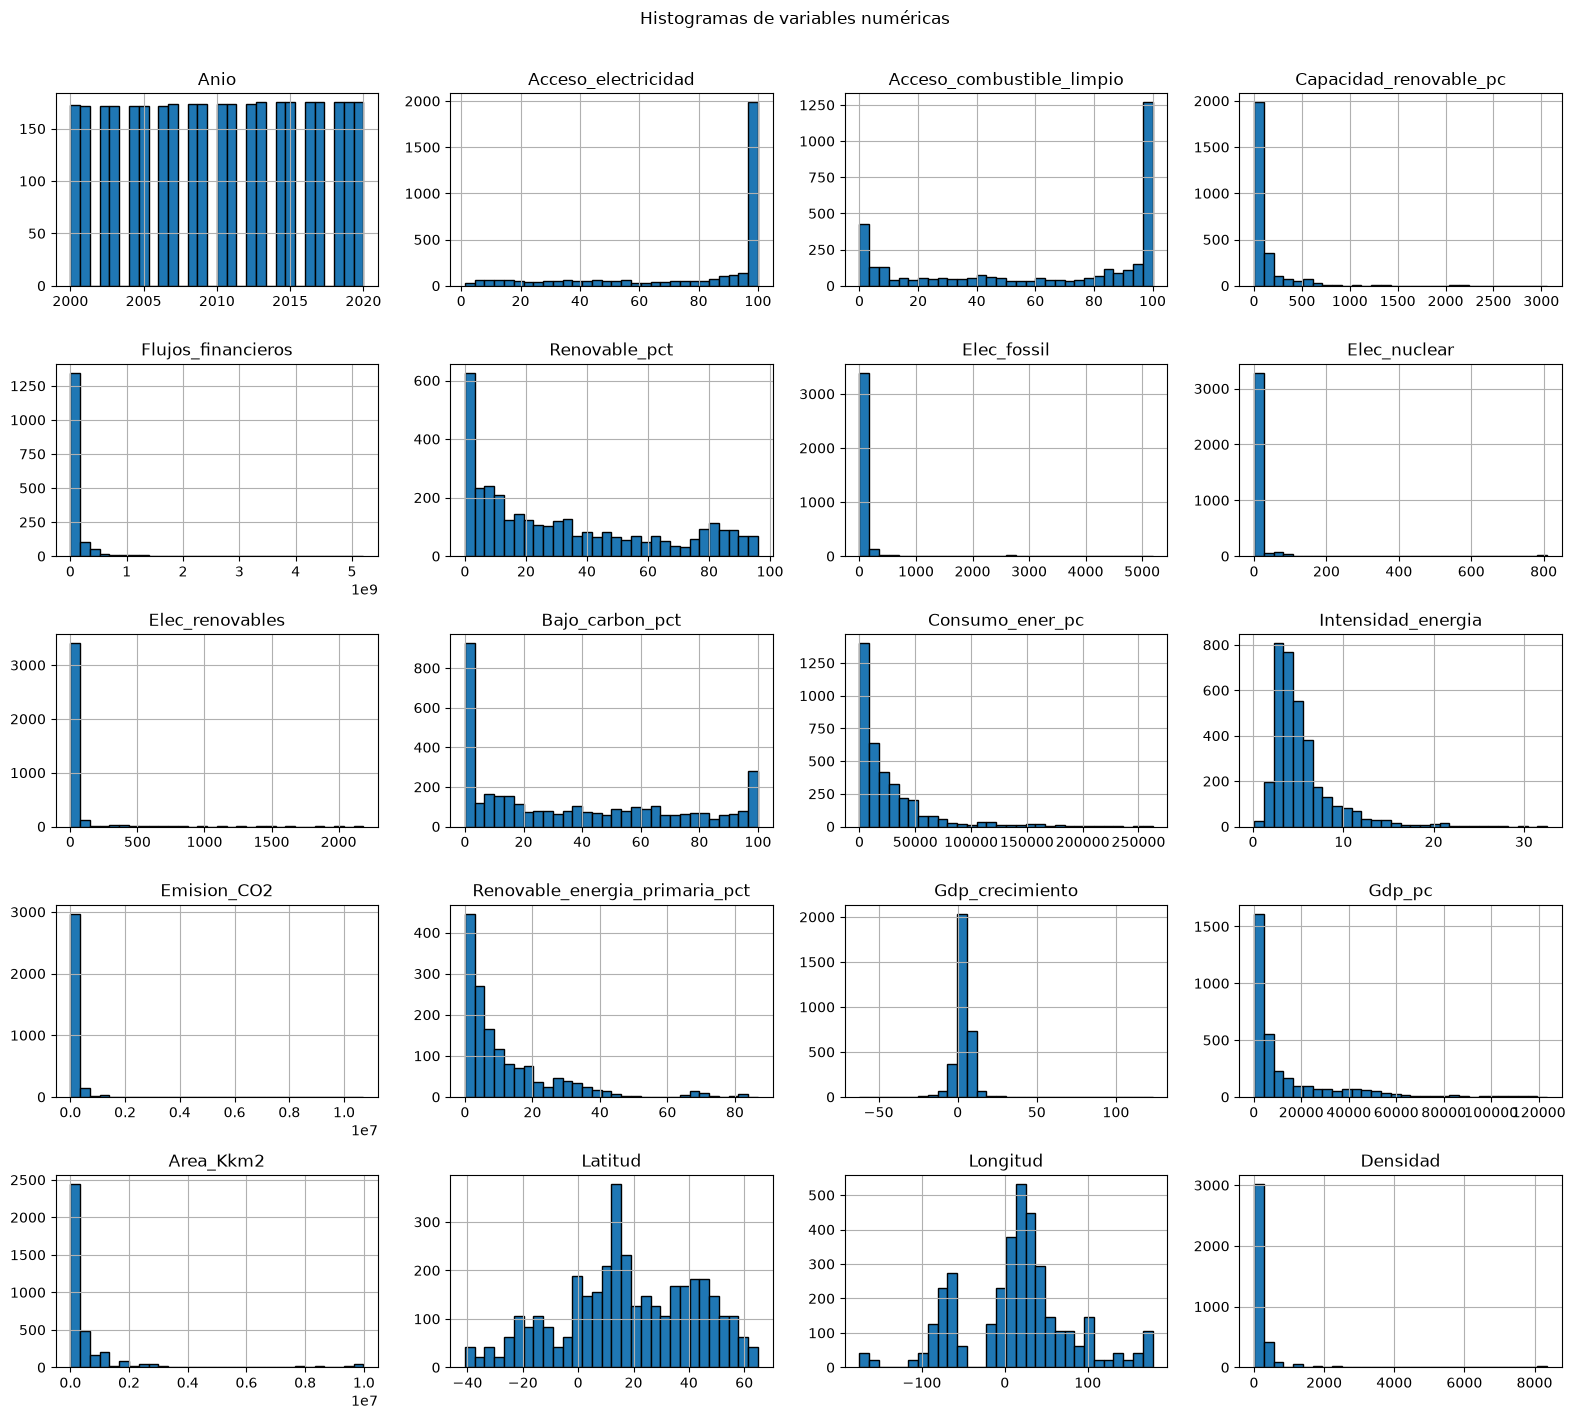

In [17]:
# Distribuciones de todas las variables numéricas
num_cols = df.select_dtypes(include="number").columns
df[num_cols].hist(figsize=(16, 14), bins=30, edgecolor="black")
plt.suptitle("Histogramas de variables numéricas", y=1.01)
plt.tight_layout()
plt.show()

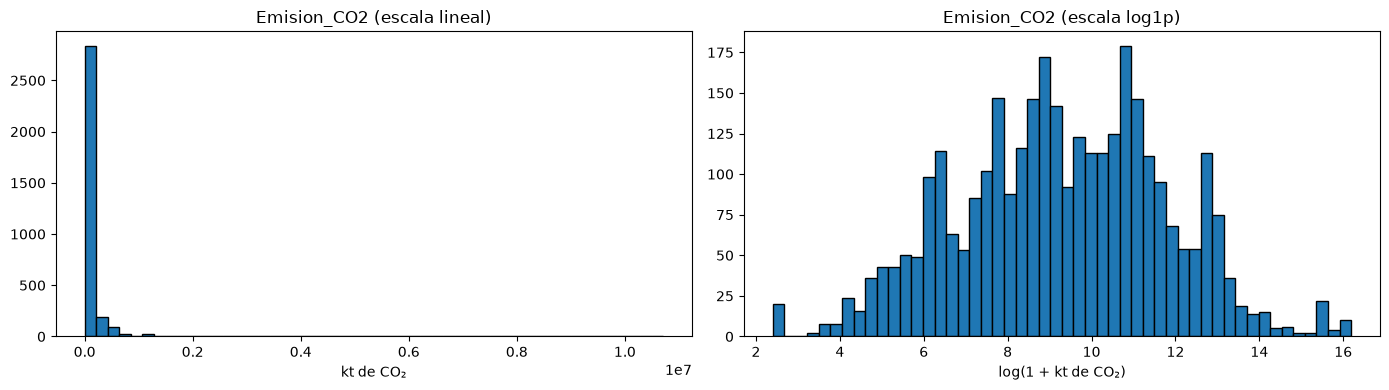

Asimetría (skew) del target: 9.34
Mediana: 10500.0 kt | Máximo: 10707220 kt


In [18]:
# Distribución del target en escala lineal y logarítmica
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["Emision_CO2"].dropna(), bins=50, edgecolor="black")
axes[0].set_title("Emision_CO2 (escala lineal)")
axes[0].set_xlabel("kt de CO₂")
axes[1].hist(np.log1p(df["Emision_CO2"].dropna()), bins=50, edgecolor="black")
axes[1].set_title("Emision_CO2 (escala log1p)")
axes[1].set_xlabel("log(1 + kt de CO₂)")
plt.tight_layout()
plt.show()

print("Asimetría (skew) del target:", round(df["Emision_CO2"].skew(), 2))
print("Mediana:", df["Emision_CO2"].median(), "kt | Máximo:", round(df["Emision_CO2"].max()), "kt")

Outliers por criterio IQR (top 8):
Elec_nuclear              578
Elec_renovables           533
Elec_fossil               518
Emision_CO2               471
Area_Kkm2                 420
Gdp_pc                    416
Longitud                  315
Capacidad_renovable_pc    301
dtype: int64


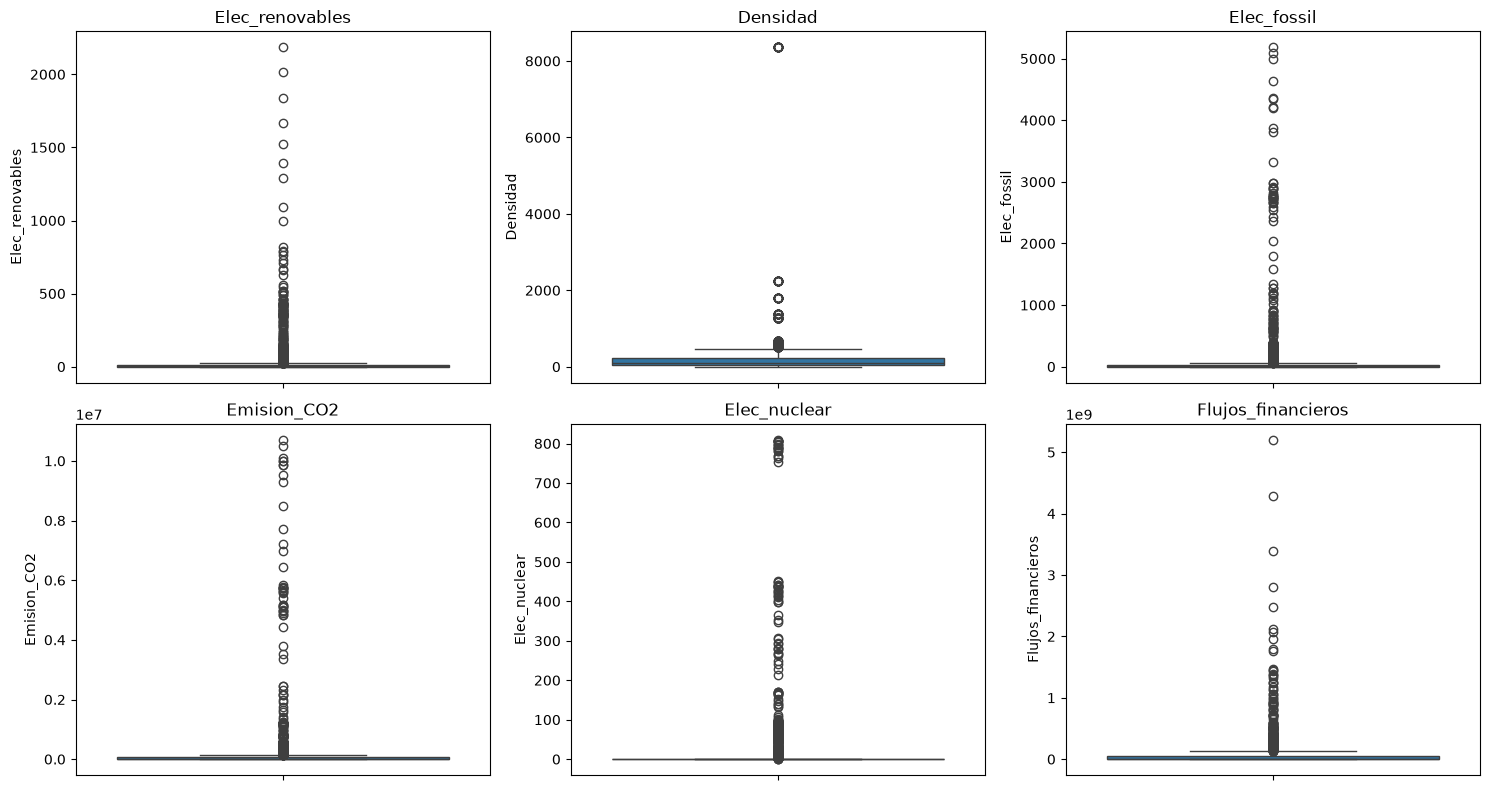

In [19]:
# Conteo de outliers por criterio IQR y boxplots de las variables más asimétricas
outliers_iqr = {}
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers_iqr[col] = int(((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum())

print("Outliers por criterio IQR (top 8):")
print(pd.Series(outliers_iqr).sort_values(ascending=False).head(8))

mas_sesgadas = df[num_cols].skew().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(mas_sesgadas):
    sns.boxplot(y=df[col], ax=axes.flatten()[i])
    axes.flatten()[i].set_title(col)
plt.tight_layout()
plt.show()

### **Observaciones:**

* La gran mayoría de las variables presenta fuerte asimetría a la derecha: pocas observaciones muy grandes y una masa concentrada en valores bajos. Las más extremas son `Elec_renovables` (skew 11,1), `Densidad` (10,0), `Elec_fossil` (9,4) y el propio target `Emision_CO2` (9,3).
* El target es el caso más relevante: la mediana es 10.500 kt pero el máximo supera los 10,7 millones de kt (China). En escala logarítmica la distribución se vuelve aproximadamente simétrica, lo que sugiere evaluar el target con tranformación logarítmica.
* Con el criterio IQR, las variables de electricidad y el target concentran cientos de outliers (471 solo en `Emision_CO2`). Sin embargo, los boxplots muestran que corresponden a países reales de gran escala (China, Estados Unidos, India), no a errores de medición.

## 3.3 EDA bivariado

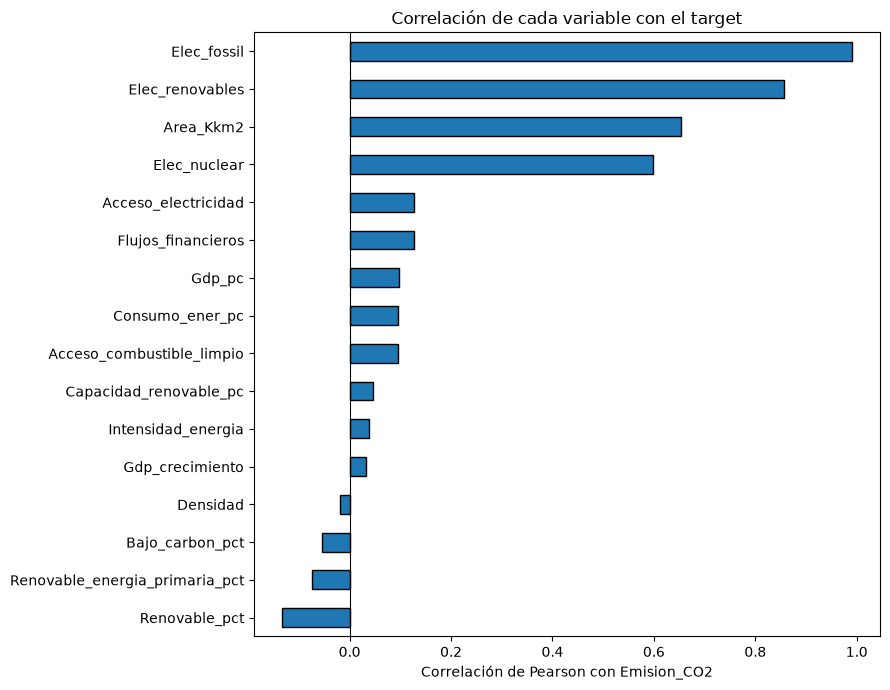

In [20]:
# Correlación de cada variable numérica con el target
corr_target = (
    df[num_cols].corr()["Emision_CO2"]
    .drop(["Emision_CO2", "Anio", "Latitud", "Longitud"])
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 7))
corr_target.plot(kind="barh", ax=ax, edgecolor="black")
ax.set_xlabel("Correlación de Pearson con Emision_CO2")
ax.set_title("Correlación de cada variable con el target")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

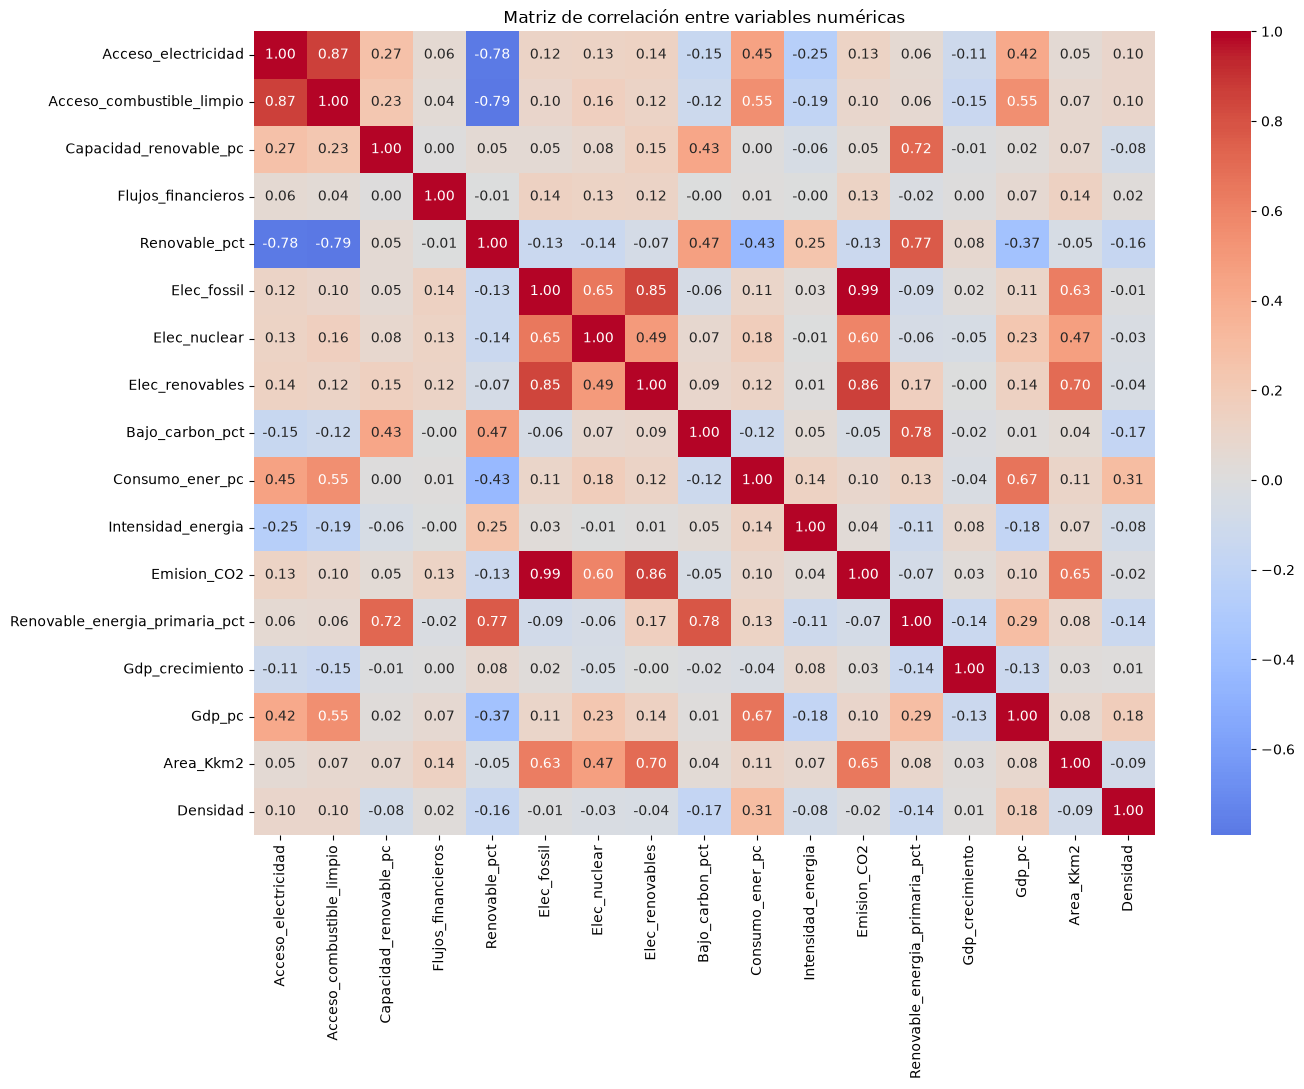

In [21]:
# Matriz de correlaciones completa
cols_corr = [c for c in num_cols if c not in ["Anio", "Latitud", "Longitud"]]
plt.figure(figsize=(14, 11))
sns.heatmap(df[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

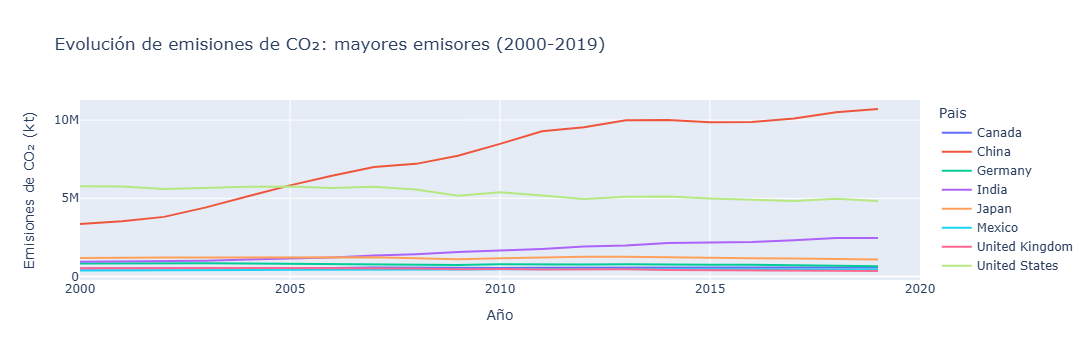

In [22]:
# Evolución temporal de emisiones para los países de mayor emisión promedio
top_emisores = (
    df.groupby("Pais")["Emision_CO2"].mean()
    .sort_values(ascending=False).head(8).index.tolist()
)

fig = px.line(
    df[df["Pais"].isin(top_emisores)],
    x="Anio", y="Emision_CO2", color="Pais",
    labels={"Anio": "Año", "Emision_CO2": "Emisiones de CO₂ (kt)"},
    title="Evolución de emisiones de CO₂: mayores emisores (2000-2019)"
)
fig.show()

### **Observaciones:**

* `Elec_fossil` correlaciona 0,99 con el target. No es una coincidencia estadística: la quema de combustibles fósiles para generar electricidad es directamente una fuente de las emisiones que el modelo intenta predecir. Esta cercanía causal implica que un R² alto del modelo estará dominado por esta variable, y motiva evaluar una variante del modelo sin ella (sección 6) para cuantificar su peso.
* Las tres variables de generación eléctrica están además fuertemente correlacionadas entre sí (`Elec_fossil` y `Elec_renovables` correlacionan 0,85): los países que generan mucho de una fuente tienden a generar mucho de todas, porque el tamaño del país domina.
* `Area_Kkm2` (0,65) también correlaciona por la vía del tamaño. Las variables per cápita y de acceso, que sí capturan características estructurales y no tamaño, muestran correlaciones débiles con el target (entre -0,13 y 0,13).
* En la serie temporal destacan dos trayectorias: China, que crece sostenido y supera a Estados Unidos en 2005, llegando a triplicar su nivel inicial, e India, que también crece durante todo el período y supera a Japón cerca de 2007. Estados Unidos desciende gradualmente, y el resto de los grandes emisores (Japón, Alemania, Canadá, Reino Unido, México) se mantiene relativamente estable en niveles mucho menores.

# 4. Fase Transformación

## 4.1 Eliminación de columnas con exceso de nulos

In [23]:
# Se eliminan las dos columnas que superaron el 50% de nulos en el diagnóstico (3.1)
# Se usa errors='ignore' para evitar errores si se ejecuta la celda más de una vez
df = df.drop(columns=[
    "Flujos_financieros",
    "Renovable_energia_primaria_pct"
], errors='ignore')
df.shape

(3649, 20)

### **Observaciones:**

* Se eliminan las dos columnas que en el diagnóstico (3.1) superaron el 50% de nulos. Imputar más de la mitad de una columna equivaldría a inventar la mayoría de sus datos.

## 4.2 Eliminación de filas sin target

In [24]:
# No se puede entrenar sin la variable objetivo
df = df.dropna(subset=["Emision_CO2"])
df.shape

(3221, 20)

### **Observaciones:**

* Se eliminaron las 428 filas sin valor de `Emision_CO2` identificadas en 3.1, quedando 3.221 filas. No es posible entrenar ni evaluar sin la variable objetivo, y como se observó en el diagnóstico, esto deja 13 países fuera del análisis.

## 4.3 Merge con los datos de la API

In [25]:
# Los DataFrames de la API traen la columna year; se traduce a Anio
# para calzar con el df principal
df_population = df_population.rename(columns={"year": "Anio"})
df_urbanization = df_urbanization.rename(columns={"year": "Anio"})

# Realizamos el merge con los datos de población y urbanización descargados
df = df.merge(df_population, on=["iso3", "Anio"], how="left")
df = df.merge(df_urbanization, on=["iso3", "Anio"], how="left")

# Verificación de nulos en las columnas nuevas
print("Nulos tras el merge:")
print(df[["Poblacion", "Urbanizacion"]].isnull().sum())
df.shape

Nulos tras el merge:
Poblacion       0
Urbanizacion    0
dtype: int64


(3221, 22)

### **Observaciones:**

* El merge no dejó ningún nulo en `Poblacion` ni `Urbanizacion`, las 3.221 filas encontraron su dato. Los registros que la API no entregó corresponden a filas que ya habían salido del dataset al eliminar las que no tenían target.
* El dataset queda con 22 columnas.

## 4.4 Imputación de nulos restantes

Estrategia en dos pasos:

* **Primero:** mediana por país (si el país tiene datos para otros años, se usa su propia mediana).
* **Segundo:** lo que quede sin imputar (países sin ningún dato en esa columna), mediana global.

Esta estrategia se apoya en lo observado en 3.2: al ser las distribuciones fuertemente asimétricas, la mediana es más robusta que la media como valor de imputación.

In [26]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    # Mediana por país
    df[col] = df.groupby("Pais")[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Mediana global para lo que quede
    df[col] = df[col].fillna(df[col].median())

# Verificación: no deben quedar nulos en columnas numéricas
df[numeric_cols].isnull().sum().sum()


np.int64(0)

## 4.5 Tratamiento de outliers

**Decisión: se conservan todos los outliers.**

El diagnóstico de 3.2 mostró cientos de valores extremos por criterio IQR, pero el análisis de los boxplots y de los mayores emisores confirma que corresponden a países reales de gran escala (China, Estados Unidos, India), no a errores de captura ni inconsistencias. Eliminarlos o recortarlos significaría excluir del análisis precisamente a los países que más importan para la pregunta central del proyecto.

El costo de esta decisión es que las métricas de error absoluto (MAE, RMSE) quedarán dominadas por estos países de gran magnitud, lo que se abordará en el modelado con transformación logarítmica donde el modelo lo requiera.

## 4.6 Feature engineering

Se construye una única feature derivada: el **ratio de electricidad renovable sobre el total generado**, que sintetiza tres columnas en una métrica interpretable entre 0 y 1.

In [27]:
total_generacion = df["Elec_fossil"] + df["Elec_nuclear"] + df["Elec_renovables"]
df["renovable_ratio"] = df["Elec_renovables"] / total_generacion

# Casos donde el total de generación es 0 producen 0/0 = NaN.
# Se imputan con 0: si un país no genera electricidad de ninguna fuente,
# su ratio renovable es 0 por definición.
print("Casos 0/0:", df["renovable_ratio"].isnull().sum())
df["renovable_ratio"] = df["renovable_ratio"].fillna(0)

df["renovable_ratio"].describe()

Casos 0/0: 17


count    3221.000000
mean        0.332290
std         0.333817
min         0.000000
25%         0.025948
50%         0.194282
75%         0.592437
max         1.000000
Name: renovable_ratio, dtype: float64

### **Observaciones:**

* Existen 17 filas donde la generación total reportada es 0 en las tres fuentes, lo que produce una división 0/0. Se imputan con ratio 0.

# 5. Fase Carga

In [28]:

def load_data(df, path="data/processed/sustainable_energy_clean.csv"):
    """Guarda el DataFrame procesado como CSV limpio."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_csv(path, index=False)

load_data(df)
print("Dataset limpio guardado:", df.shape)

Dataset limpio guardado: (3221, 23)


# 6. Preparación específica y modelado

Esta sección aborda dos cosas: la preparación de datos que existe para beneficio del modelo, y el entrenamiento.

La preparación fue repartida con un criterio simple: ¿a quién le sirve la transformación? Lo que le sirve a todos los que consumen el dataset (imputar nulos, botar columnas, cruzar con la API, construir variables) está en la fase 4 y queda guardado en el CSV limpio. Lo que le sirve solo a un modelo específico, como el escalado y las transformaciones logarítmicas, vive acá: el CSV debe conservar las unidades originales (kt, TWh) para mantener la interpretabilidad del dashboard.

El escalado además tiene que ir después del split, porque se ajusta calculando media y desviación. Si se hiciera antes, esas estadísticas incluirían al conjunto de test.

## 6.1 Definición de features y target

In [29]:
feature_cols = [
    "Acceso_electricidad", "Acceso_combustible_limpio", "Capacidad_renovable_pc",
    "Renovable_pct", "Elec_fossil", "Elec_nuclear", "Elec_renovables",
    "Bajo_carbon_pct", "Consumo_ener_pc", "Intensidad_energia",
    "Gdp_crecimiento", "Gdp_pc", "Densidad", "Area_Kkm2",
    "Poblacion", "Urbanizacion", "renovable_ratio"
]
X = df[feature_cols]
y = df["Emision_CO2"]

print("X:", X.shape)
print("y:", y.shape)

X: (3221, 17)
y: (3221,)


## 6.2 Train/test split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (2576, 17) | Test: (645, 17)


## 6.3 Escalado

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6.4 Entrenamiento y comparación de modelos

Se entrenan tres modelos con la misma interfaz de sklearn y se comparan con R², MAE y RMSE sobre el conjunto de test. El modelo final se elige según R².

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def crear_modelos():
    """Devuelve instancias nuevas de los tres modelos a comparar."""
    return {
        "Linear Regression": LinearRegression(),
        "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
    }

def evaluar(y_real, y_pred):
    """Calcula las tres métricas de regresión."""
    return {
        "R2": r2_score(y_real, y_pred),
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred))
    }

models = crear_modelos()
resultados = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    resultados[name] = evaluar(y_test, y_pred)
    print(f"{name}:")
    print(f"  R²:   {resultados[name]['R2']:.4f}")
    print(f"  MAE:  {resultados[name]['MAE']:.2f}")
    print(f"  RMSE: {resultados[name]['RMSE']:.2f}")

Linear Regression:
  R²:   0.9872
  MAE:  32667.48
  RMSE: 78263.90
KNN Regressor:
  R²:   0.9969
  MAE:  9537.25
  RMSE: 38475.99
Random Forest:
  R²:   0.9982
  MAE:  5359.08
  RMSE: 29296.46


### **Observaciones:**

* Random Forest obtiene el mejor R² (0,9976), seguido de KNN (0,9969) y la regresión lineal (0,9872). Los tres quedan sobre 0,98, lo que calza con lo visto en 3.3; `Elec_fossil` tiene una correlación de 0,99 con el target.
* En MAE la diferencia entre modelos es mucho más marcada que en R². Random Forest se equivoca en promedio 5.938 kt, KNN 9.537 kt y la regresión lineal 32.667 kt. El R² casi no los distingue, pero el error absoluto sí.
* El MAE de 5.938 kt parece bajo al lado del máximo del target (10,7 millones de kt), pero es más de la mitad de la mediana (10.500 kt). Como el target está concentrado en valores bajos, el promedio del error lo levantan los países grandes.

## 6.5 Variantes de preparación

Las tres variantes son decisiones de preparación de datos: dos transformaciones y una selección de features. Su efecto depende del modelo que las use, así que en vez de aplicarlas a ciegas se comparan contra la corrida base de 6.4.

Como el objetivo es predictivo, el modelo final se elige por desempeño y estas variantes no compiten por ese puesto: son **diagnóstico**. Permiten entender de dónde viene el desempeño y anticipar las preguntas que el resultado genera.

* **Variante A (target en escala logarítmica):** la distribución del target es extremadamente asimétrica (3.2). Entrenar sobre `log1p(y)` y evaluar de vuelta en kt permite comprobar si la transformación mejora la estimación, especialmente en países de emisiones bajas y medias. Precaución al interpretar: el error de la regresión lineal en escala log puede amplificarse al volver a kt con `expm1`.
* **Variante B (sin la variable dominante):** `Elec_fossil` correlaciona 0,99 con el target (3.3) porque la generación eléctrica con combustibles fósiles es directamente una fuente de las emisiones. Bajo un objetivo predictivo su uso es legítimo, pero conviene cuantificar cuánto del desempeño depende de ella: reentrenar sin la variable muestra qué logra el modelo apoyándose solo en el resto del perfil del país.
* **Variante C (features en escala logarítmica):** el EDA univariado (3.2) mostró que la asimetría extrema no es exclusiva del target y que varias features la comparten. Se aplica `log1p` a las features sesgadas (asimetría mayor a 2 y sin valores negativos) además del target, lo que beneficia a los modelos sensibles a la escala (regresión lineal y KNN). Para Random Forest es irrelevante: las transformaciones monótonas no alteran los cortes de los árboles.

In [33]:
# Variante A: target en escala logarítmica
resultados_log = {}
for name, model in crear_modelos().items():
    model.fit(X_train_scaled, np.log1p(y_train))
    y_pred = np.expm1(model.predict(X_test_scaled))
    resultados_log[name] = evaluar(y_test, y_pred)
    print(f"{name} (target log):")
    print(f"  R²:   {resultados_log[name]['R2']:.4f}")
    print(f"  MAE:  {resultados_log[name]['MAE']:.2f}")
    print(f"  RMSE: {resultados_log[name]['RMSE']:.2f}")

Linear Regression (target log):
  R²:   -151.8528
  MAE:  712138.31
  RMSE: 8552347.94
KNN Regressor (target log):
  R²:   0.9963
  MAE:  9356.58
  RMSE: 42301.04
Random Forest (target log):
  R²:   0.9963
  MAE:  7048.49
  RMSE: 41845.12


In [34]:
# Variante B: sin la variable de mayor correlación absoluta con el target
corr_features = df[feature_cols + ["Emision_CO2"]].corr()["Emision_CO2"].drop("Emision_CO2")
var_dominante = corr_features.abs().idxmax()
print("Variable dominante según correlación:", var_dominante, f"({corr_features[var_dominante]:.3f})\n")

features_sin_dominante = [c for c in feature_cols if c != var_dominante]

from sklearn.preprocessing import StandardScaler
scaler_sin = StandardScaler()
X_train_sin = scaler_sin.fit_transform(X_train[features_sin_dominante])
X_test_sin = scaler_sin.transform(X_test[features_sin_dominante])

resultados_sin = {}
for name, model in crear_modelos().items():
    model.fit(X_train_sin, y_train)
    y_pred = model.predict(X_test_sin)
    resultados_sin[name] = evaluar(y_test, y_pred)
    print(f"{name} (sin {var_dominante}):")
    print(f"  R²:   {resultados_sin[name]['R2']:.4f}")
    print(f"  MAE:  {resultados_sin[name]['MAE']:.2f}")
    print(f"  RMSE: {resultados_sin[name]['RMSE']:.2f}")

Variable dominante según correlación: Elec_fossil (0.990)

Linear Regression (sin Elec_fossil):
  R²:   0.8382
  MAE:  129475.65
  RMSE: 278257.75
KNN Regressor (sin Elec_fossil):
  R²:   0.9968
  MAE:  10245.71
  RMSE: 39334.57
Random Forest (sin Elec_fossil):
  R²:   0.9958
  MAE:  7105.87
  RMSE: 44612.32


In [35]:
# Variante C: log1p en las features sesgadas + target en log
# Se seleccionan por criterio, no a mano: asimetría > 2 y sin negativos
skew_features = X_train.skew()
features_log = [
    col for col in feature_cols
    if skew_features[col] > 2 and X_train[col].min() >= 0
]
print("Features a transformar con log1p:", features_log, "\n")

X_train_log = X_train.copy()
X_test_log = X_test.copy()
X_train_log[features_log] = np.log1p(X_train_log[features_log])
X_test_log[features_log] = np.log1p(X_test_log[features_log])

scaler_log = StandardScaler()
X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_test_log_scaled = scaler_log.transform(X_test_log)

resultados_flog = {}
for name, model in crear_modelos().items():
    model.fit(X_train_log_scaled, np.log1p(y_train))
    y_pred = np.expm1(model.predict(X_test_log_scaled))
    resultados_flog[name] = evaluar(y_test, y_pred)
    print(f"{name} (features + target log):")
    print(f"  R²:   {resultados_flog[name]['R2']:.4f}")
    print(f"  MAE:  {resultados_flog[name]['MAE']:.2f}")
    print(f"  RMSE: {resultados_flog[name]['RMSE']:.2f}")

Features a transformar con log1p: ['Capacidad_renovable_pc', 'Elec_fossil', 'Elec_nuclear', 'Elec_renovables', 'Consumo_ener_pc', 'Intensidad_energia', 'Gdp_pc', 'Densidad', 'Area_Kkm2', 'Poblacion'] 

Linear Regression (features + target log):
  R²:   0.9864
  MAE:  20085.44
  RMSE: 80653.68
KNN Regressor (features + target log):
  R²:   0.9980
  MAE:  6771.78
  RMSE: 31237.08
Random Forest (features + target log):
  R²:   0.9967
  MAE:  6962.19
  RMSE: 40007.07


### **Observaciones:**

* La Variante A no aporta. KNN (0,9963) y Random Forest (0,9974) quedan apenas por debajo del modelo base, y la regresión lineal se va a R² -151,85: el error en escala log se dispara al devolver los valores a kt con `expm1`.
* La Variante B muestra que la dependencia de `Elec_fossil` no es igual en todos los modelos. La regresión lineal cae de 0,9872 a 0,8382, pero KNN pasa de 0,9969 a 0,9968 y Random Forest de 0,9976 a 0,9966, casi no hace diferencia.
* Eso calza con lo visto en 3.3; `Elec_fossil` tiene una correlación de 0,85 con `Elec_renovables`, y además están `Poblacion` y `Area_Kkm2` midiendo porte del país. La información de esa variable está repetida en otras columnas, así que los modelos flexibles la reemplazan. La regresión lineal, que no puede combinar variables de forma no lineal, sí la necesita.
* La Variante C es la que más sirve. La regresión lineal mantiene su R² (0,9864) pero baja su MAE de 32.667 a 20.085 kt, y KNN llega a 0,9980, el mejor R² de todas las corridas.

# 7. Evaluación del modelo

## 7.1 Selección del modelo final

La selección se hace según R² sobre la comparación base (6.4), coherente con el objetivo predictivo del proyecto: se presenta el modelo que estima mejor. Los resultados de las variantes (6.5) no son criterio de selección; se usan en la discusión para explicar de dónde viene el desempeño del modelo elegido.

In [36]:
# Selección del modelo final según R²
nombre_final = max(resultados, key=lambda k: resultados[k]["R2"])
modelo_final = models[nombre_final]
print("Modelo final seleccionado:", nombre_final)

Modelo final seleccionado: Random Forest


### **Observaciones:**

* El modelo final es Random Forest, con R² 0,9976, MAE 5.938 kt y RMSE 33.677 kt.
* El RMSE es casi seis veces el MAE. Como el RMSE castiga más los errores grandes, esa diferencia indica que el modelo acierta en la mayoría de los casos pero se equivoca feo en unos pocos.
* Un punto para tener a mano en la presentación: KNN con features y target en log (Variante C) llegó a 0,9980, apenas sobre el Random Forest base. La regla de selección era la comparación base, así que el modelo final es Random Forest, pero la diferencia entre los dos es mínima.

## 7.2 Predicho vs real del modelo final

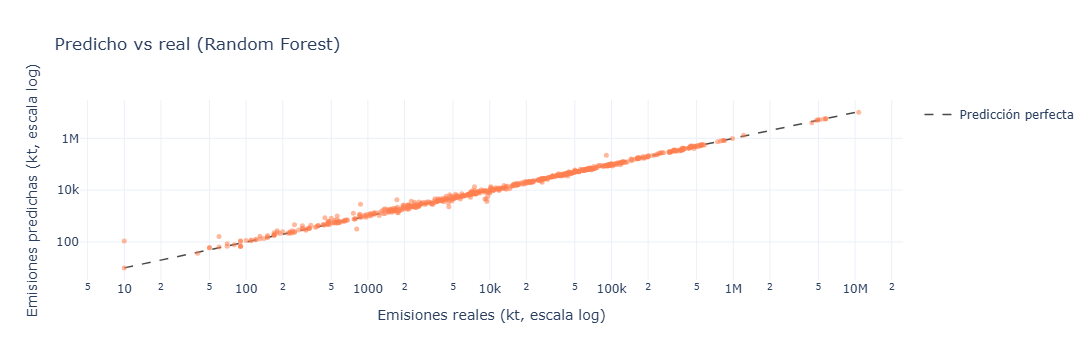

In [37]:
import plotly.graph_objects as go

y_pred_final = modelo_final.predict(X_test_scaled)

df_pred = pd.DataFrame({
    "real": y_test.values,
    "predicho": y_pred_final,
    "Pais": df.loc[X_test.index, "Pais"].values,
    "Anio": df.loc[X_test.index, "Anio"].values
})

lim_min = min(df_pred["real"].min(), df_pred["predicho"].min())
lim_max = max(df_pred["real"].max(), df_pred["predicho"].max())

# Ejes en escala log: no transforma los datos, solo cambia cómo se miran.
# En escala lineal el 99% de los puntos se apelmaza en el origen porque la
# mediana del target son 10.500 kt y el máximo 10,7 millones.
fig = px.scatter(
    df_pred, x="real", y="predicho",
    log_x=True, log_y=True,
    opacity=0.55,
    hover_data=["Pais", "Anio"],
    labels={"real": "Emisiones reales (kt, escala log)",
            "predicho": "Emisiones predichas (kt, escala log)"},
    title=f"Predicho vs real ({nombre_final})",
    template="plotly_white"
)
fig.update_traces(marker=dict(size=5, color="#FF7F50"))

# Línea de referencia
fig.add_trace(go.Scatter(
    x=[lim_min, lim_max], y=[lim_min, lim_max],
    mode="lines",
    line=dict(color="#4A4A4A", width=1.5, dash="dash"),
    name="Predicción perfecta"
))

# La línea se dibuja detrás de los puntos: add_trace la agrega al final,
# así que se invierte el orden para que los datos queden arriba
fig.data = (fig.data[1], fig.data[0])

fig.show()

### **Observaciones:**

* En escala log se ve que los puntos siguen la diagonal a lo largo de todo el rango, desde los países de 10 kt hasta China con 10,7 millones. El modelo no se cae en ninguna zona.
* La dispersión no es pareja. Sobre los 10.000 kt los puntos quedan pegados a la línea, y bajo los 1.000 kt se abren bastante. El caso más notorio es un país con 10 kt reales al que el modelo le estima cerca de 180 kt.
* Acá se ve de dónde viene la diferencia entre MAE y RMSE: los errores relativos más grandes están en los países de emisión baja, pero como esos valores son chicos en kt casi no mueven el promedio. Al revés, los países grandes se ven pegados a la diagonal y aun así sus errores en kt son los más altos de todos, y son los que suben el MAE y el RMSE.

## 7.3 Estructura del espacio de features (PCA)

El PCA proyecta las 17 features a 2 componentes. Se usa como paso previo al modelo para hacer un diagnóstico visual.

La pregunta que responde es: ¿países con perfiles energéticos y económicos similares tienen emisiones similares? Si el plano ordena a los países por nivel de emisión, entonces el perfil contiene la señal que hace posible estimar el target.

Se calculan las cargas de cada componente para poder interpretar qué representan los ejes, y se entrena un modelo usando únicamente los 2 componentes para medir cuánta señal predictiva conserva el plano.

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

print(f"Varianza explicada de las features -> PC1: {pca.explained_variance_ratio_[0]:.1%} | "
      f"PC2: {pca.explained_variance_ratio_[1]:.1%} | "
      f"Juntas: {pca.explained_variance_ratio_.sum():.1%}\n")

# Cargas: qué variables componen cada eje. Sin esto, PC1 y PC2 no son interpretables.
cargas = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
).round(3)

print("Cargas ordenadas por peso absoluto en PC1:")
print(cargas.reindex(cargas["PC1"].abs().sort_values(ascending=False).index).head(6))
print("\nCargas ordenadas por peso absoluto en PC2:")
print(cargas.reindex(cargas["PC2"].abs().sort_values(ascending=False).index).head(6))

Varianza explicada de las features -> PC1: 27.3% | PC2: 19.5% | Juntas: 46.8%

Cargas ordenadas por peso absoluto en PC1:
                             PC1    PC2
Acceso_combustible_limpio  0.390 -0.136
Renovable_pct             -0.384  0.146
Acceso_electricidad        0.375 -0.112
Urbanizacion               0.367 -0.128
Consumo_ener_pc            0.321 -0.098
Gdp_pc                     0.305 -0.079

Cargas ordenadas por peso absoluto en PC2:
                   PC1    PC2
Elec_renovables  0.177  0.462
Elec_fossil      0.192  0.460
Area_Kkm2        0.146  0.423
Poblacion        0.096  0.413
Elec_nuclear     0.182  0.291
Renovable_pct   -0.384  0.146


In [39]:
# ¿Conserva el plano la señal predictiva?
# Se entrena un modelo usando SOLO los 2 componentes y se compara con el modelo completo.
Z_train = X_pca
Z_test = pca.transform(X_test_scaled)

rf_pca = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_pca.fit(Z_train, y_train)
r2_2comp = r2_score(y_test, rf_pca.predict(Z_test))

print(f"R² usando solo los 2 componentes:        {r2_2comp:.4f}")
print(f"R² usando las {len(feature_cols)} features completas:  {resultados['Random Forest']['R2']:.4f}")
print(f"\nDiferencia: {resultados['Random Forest']['R2'] - r2_2comp:.4f}")

R² usando solo los 2 componentes:        0.9864
R² usando las 17 features completas:  0.9982

Diferencia: 0.0119


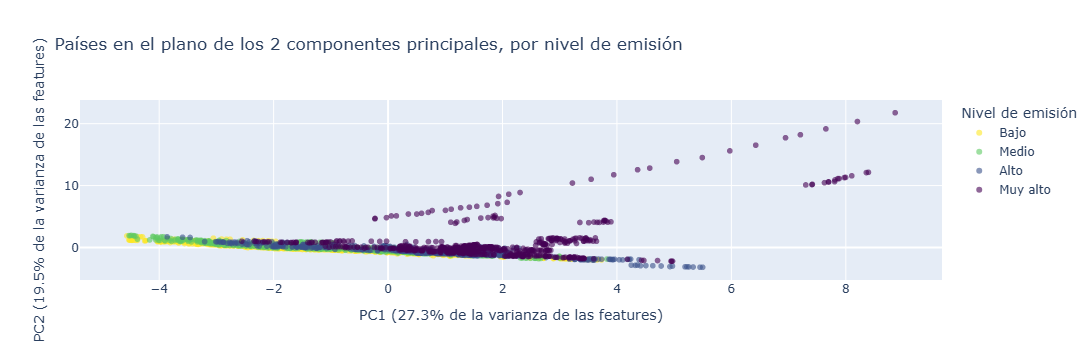

In [40]:
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Pais": df.loc[X_train.index, "Pais"].values,
    "Anio": df.loc[X_train.index, "Anio"].values,
    "Emision_CO2": y_train.values
})

# Color por tramos de cuartil en vez de escala continua: la cola derecha del target
# es tan extrema que en escala continua casi todos los puntos se ven del mismo color.
df_pca["Nivel de emisión"] = pd.qcut(
    y_train.values, q=4, labels=["Bajo", "Medio", "Alto", "Muy alto"]
)

fig = px.scatter(
    df_pca, x="PC1", y="PC2",
    color="Nivel de emisión",
    category_orders={"Nivel de emisión": ["Bajo", "Medio", "Alto", "Muy alto"]},
    color_discrete_sequence=["#fde725", "#5ec962", "#3b528b", "#440154"],
    opacity=0.6,
    hover_data=["Pais", "Anio", "Emision_CO2"],
    labels={
        "PC1": f"PC1 ({pca.explained_variance_ratio_[0]:.1%} de la varianza de las features)",
        "PC2": f"PC2 ({pca.explained_variance_ratio_[1]:.1%} de la varianza de las features)"
    },
    title="Países en el plano de los 2 componentes principales, por nivel de emisión"
)
fig.update_traces(marker=dict(size=6))
fig.show()

### **Observaciones:**

* PC1 explica 27,3% de la varianza de las features y PC2 un 19,5%, o sea 46,8% entre los dos.
* Según las cargas, los ejes tienen una lectura bastante clara. PC1 junta `Acceso_combustible_limpio` (0,390), `Renovable_pct` (-0,384), `Acceso_electricidad` (0,375), `Urbanizacion` (0,367), `Consumo_ener_pc` (0,321) y `Gdp_pc` (0,305): es un eje de desarrollo. PC2 junta `Elec_renovables` (0,462), `Elec_fossil` (0,460), `Area_Kkm2` (0,423) y `Poblacion` (0,413): es un eje de escala, o sea de porte del país.
* `Renovable_pct` carga negativo en PC1 mientras el acceso a servicios y el PIB cargan positivo, lo que sugiere que los países con mayor participación renovable en su consumo son los menos desarrollados del dataset.
* Un modelo entrenado solo con los 2 componentes llega a R² 0,9864, contra 0,9976 con las 17 features. Se pierde apenas 0,0113 al pasar de 17 dimensiones a 2, así que el plano conserva casi toda la señal.
* En el plano hay un ordenamiento claro a lo largo de PC1: los países de emisión baja y media se agrupan a la izquierda y al centro, y los de emisión alta y muy alta se corren hacia la derecha. Los "muy alto" además se despegan hacia arriba en PC2, o sea por el eje de escala.
* Los niveles bajo y medio se superponen casi por completo, así que el plano no los distingue. Alto y muy alto sí quedan bien separados.
* Las líneas de puntos que suben hacia la derecha, despegadas de la masa principal, parecen ser trayectorias: cada una sería un mismo país a lo largo de los años. El hover permite confirmar cuáles son.

**Nota:** la varianza explicada y el R² miden objetos distintos. Un plano puede capturar una fracción modesta de la variación entre países y aun así conservar casi toda la información sobre el target, porque la variación descartada no se relaciona con las emisiones.

# 8. Conclusiones

## 8.1 Reflexiones finales

* La respuesta a la pregunta central es sí. El modelo final (Random Forest) estima las emisiones con R² 0,9976 y MAE 5.938 kt, y la estimación se sostiene a lo largo de seis órdenes de magnitud.
* La estimación no depende de una sola variable, que era la sospecha razonable al ver que `Elec_fossil` correlaciona 0,99 con el target. Sacarla apenas baja el R² de Random Forest de 0,9976 a 0,9966 (muy poco). La información sobre emisiones está repartida en varias columnas que miden las métricas del país de forma multifactorial, así que el modelo se las arregla sin ella. La única que la echa de menos de verdad es la regresión lineal, que cae de 0,9872 a 0,8382 porque no puede combinar variables de forma no lineal.
* El PCA muestra lo mismo desde otro ángulo: 2 componentes que resumen el 46,8% de la variación entre países bastan para llegar a R² 0,9864. El perfil energético y económico contiene la señal, y no hace falta usarlo completo.
* Sobre el caso de uso de 1.1 (países sin reporte de emisiones de CO2), el modelo sirve para completar registros de países que sí reportan su matriz energética. Los 13 países que no reportan emisiones en ningún año quedaron fuera del entrenamiento: para ellos el modelo puede estimar, pero no se puede comprobar si acierta.

## 8.2 Limitaciones

* El MAE y el RMSE mezclan escalas muy distintas. Un país grande puede tener un error enorme en kt aunque relativamente acierte, y uno chico un error mínimo en kt aunque se equivoque por mucho en proporción. Por eso el RMSE (33.677) es casi seis veces el MAE (5.938).
* Ninguna de las métricas usadas dice qué tan bien estima el modelo en un país típico. El R² tampoco: con un rango que va de 10 kt a 10,7 millones, distinguir 5.000 de 15.000 kt casi no lo mueve.
* El plano del PCA superpone los niveles bajo y medio, donde cae la mayoría de los países. La señal es más débil justo donde hay más casos.
* 13 países quedan fuera por no tener target en ningún año, y son justamente parte de los registros que el modelo buscaría complementar.
* La imputación cae a mediana global cuando un país no tiene ningún dato en una columna, lo que introduce ruido en variables como el PIB.
* La validación mide la estimación de observaciones país y año dentro del período observado, no el pronóstico de años futuros. Un uso de pronóstico requeriría un split temporal y una evaluación distinta.
El valor mínimo del target es exactamente 10 kt y se repite en varios países chicos, lo que sugiere que la fuente redondea o trunca las emisiones bajas. En ese tramo el modelo estaría aprendiendo de datos poco precisos.
La API no entregó los 21 años para todos los países (3.675 de 3.696 registros posibles), aunque los faltantes no afectaron el dataset final.

## 8.3 Pasos y mejoras potenciales

* Hacer validación cruzada y ajuste de hiperparámetros del modelo final.
* Features per cápita para separar el efecto del tamaño del país de sus características estructurales.
* Incorporar más indicadores de la API del World Bank que puedan aportar información adicional a los modelos.
* Evaluar el modelo estimando específicamente los registros faltantes de emisiones, por ejemplo imputando con KNN las regiones con datos faltantes.
* Reportar las métricas por tramo de emisión (bajo, medio, alto), para saber dónde el modelo estima mejor y peor sin necesidad de una métrica nueva.
* Probar la imputación por interpolación temporal dentro de cada país (los años vecinos se parecen), en vez de mediana por país.